<a href="https://colab.research.google.com/github/sn0wst0rm-dot/Dynamic-Tariff-Optimization-for-EV-Charging-Networks/blob/main/Dyanmic_Tariff_Optimization_for_EV_Charging_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***
# **Algorithmic Tariff Orchestration in Electric Vehicle Charging Networks**
*Integrated Reinforcement Learning and Elastic Demand Modeling for Grid Stability*

---
**Pranit Garg | 24115115**\
*Electrical Engineering, IIT Roorkee*

</div>

***

---

# 🚀 Closed-Loop Dynamic Tariff Orchestration: A Feedback-Informed Deep Reinforcement Learning System


## 🎯 Objective

This project is based on implementatiton of an intelligent **Dynamic Tariff Pricing Agent** for EV charging infrastructure. The primary goal is to mitigate "Grid Congestion" by dynamically adjusting electricity prices based on local station utilization, time-of-use (TOU) tariffs, and predicted demand elasticity.

---

## 🏗️ Technical Architecture

We employ a **Deep Reinforcement Learning (DRL) Framework** that acts as the brain for each charging zone.

1. **State Representation (The Grid View):** The agent observes the current hour, day of the week, local utilization rate, and historical price volatility.
2. **The Demand Model (The World Model):** An XGBoost regressor that predicts energy volume demand. It has been trained to understand price elasticity—the fundamental law that consumers reduce demand as prices increase.
3. **The Decision Engine (DQN):** A Deep Q-Network (DQN) that selects optimal pricing from 5 tiers (₹10–₹22/kWh).
4. **Reward Shaping (The Behavioral Guide):**
* **Utilization Bonus:** Rewards the agent for keeping utilization in the "sweet spot" (40–75%).
* **Congestion Penalty:** A harsh tax for pricing too low during peak hours, discouraging the "Bang-Bang" monopoly behavior.
* **Idle Penalty:** A financial fine for stations that remain under-utilized, forcing the agent to discover off-peak discounts.
---

## 📊 Methodology & Rubric

The agent is judged on its ability to optimize the **Social Welfare** of the charging station network.

<table style="width:100%; border-collapse: collapse;">
  <thead>
    <tr style="background-color: #333; color: white;">
      <th style="padding: 12px; text-align: left; width: 20%;">Metric</th>
      <th style="padding: 12px; text-align: left; width: 15%;">Goal</th>
      <th style="padding: 12px; text-align: left; width: 65%;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 12px; border-bottom: 1px solid #ddd; font-weight: bold;">Revenue Gain</td>
      <td style="padding: 12px; border-bottom: 1px solid #ddd;">Δ > 5%</td>
      <td style="padding: 12px; border-bottom: 1px solid #ddd;">Financial improvement achieved by moving from flat-rate to dynamic pricing.</td>
    </tr>
    <tr>
      <td style="padding: 12px; border-bottom: 1px solid #ddd; font-weight: bold;">Utilization Shift</td>
      <td style="padding: 12px; border-bottom: 1px solid #ddd;">Δ ≈ 0%</td>
      <td style="padding: 12px; border-bottom: 1px solid #ddd;">Preventing the "Over-Congestion" trap while improving load distribution.</td>
    </tr>
    <tr>
      <td style="padding: 12px; border-bottom: 1px solid #ddd; font-weight: bold;">Off-Peak Uplift</td>
      <td style="padding: 12px; border-bottom: 1px solid #ddd;">Δ > 30%</td>
      <td style="padding: 12px; border-bottom: 1px solid #ddd;">Successful volume shifting (peak shaving) during low-demand periods.</td>
    </tr>
  </tbody>
</table>

---

## ⚙️ The Learning Loop: "Feedback-Informed Design"

The pipeline is designed to be self-improving:

1. **Data Alignment:** We unify disparate datasets (ACN California, UrbanEV Shenzhen) to simulate global grid conditions.
2. **Training:** The DQN trains for 300+ episodes, learning to navigate the trade-off between maximizing revenue and maintaining grid reliability.
3. **Monitoring & Auto-Tuning:** After every evaluation, our **Monitoring Agent** generates a feedback loop. If the agent misses surge opportunities, the monitoring agent signals the reward function to increase "Surge Aggression" for the next training iteration.

---

In [ ]:
from google.colab import drive
import pandas as pd
import os
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/SocBiz_Open_Project'
ACN_DATA_PATH = '/content/drive/MyDrive/SocBiz_Open_Project/Datasets_OP_26_Analytics/ACN_Data/acndata_sessions.json.xlsx'
URBAN_EV_DATA_PATH = '/content/drive/MyDrive/SocBiz_Open_Project/Datasets_OP_26_Analytics/UrbanEV_ SZ_Districts'
PATHS = {
    'adj': os.path.join(URBAN_EV_DATA_PATH, 'adj.csv'),
    'distance': os.path.join(URBAN_EV_DATA_PATH, 'distance.csv'),
    'duration': os.path.join(URBAN_EV_DATA_PATH, 'duration.csv'),
    'information': os.path.join(URBAN_EV_DATA_PATH, 'information.csv'),
    'stations': os.path.join(URBAN_EV_DATA_PATH, 'stations.csv'),
    'volume': os.path.join(URBAN_EV_DATA_PATH, 'volume.csv'),
    'occupancy': os.path.join(URBAN_EV_DATA_PATH, 'occupancy.csv'),
    'price': os.path.join(URBAN_EV_DATA_PATH, 'price.csv'),
    'time': os.path.join(URBAN_EV_DATA_PATH, 'time.csv')
}
print("Loading UrbanEV datasets...")
adj_matrix_df = pd.read_csv(PATHS['adj'], header=None)
time_df = pd.read_csv(PATHS['time'])
volume_df = pd.read_csv(PATHS['volume'])
occupancy_df = pd.read_csv(PATHS['occupancy'])
price_df = pd.read_csv(PATHS['price'])
acn_df = pd.read_excel(ACN_DATA_PATH)
print("✅ Successfully loaded all UrbanEV component matrices and ACN Data")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading UrbanEV datasets...
✅ Successfully loaded all UrbanEV component matrices and ACN Data


##Data Preprocessing and Feature Engineering

In [ ]:
import pandas as pd
import numpy as np

class EVDataProcessor:
    def __init__(self, acn_df, urban_df, adjacency_matrix, freq='1h'):
        self.acn = acn_df.copy()
        self.urban = urban_df.copy()
        self.adj_matrix = adjacency_matrix
        self.freq = freq

    def preprocess_acn(self):
        self.acn['connectionTime'] = pd.to_datetime(self.acn['connectionTime'])
        self.acn['disconnectTime'] = pd.to_datetime(self.acn['disconnectTime'])
        self.acn = self.acn[self.acn['kWhDelivered'] > 0.1]
        dwell_times = (self.acn['disconnectTime'] - self.acn['connectionTime']).dt.total_seconds()
        cap_limit = dwell_times.quantile(0.95)
        missing_mask = self.acn['disconnectTime'].isna()
        self.acn.loc[missing_mask, 'disconnectTime'] = self.acn.loc[missing_mask, 'connectionTime'] + pd.Timedelta(seconds=cap_limit)
        self.acn['parking_duration'] = (self.acn['disconnectTime'] - self.acn['connectionTime']).dt.total_seconds() / 3600

    def align_and_merge(self):
        time_grid = pd.date_range(start=self.urban['timestamp'].min(),
                                  end=self.urban['timestamp'].max(),
                                  freq=self.freq)
        self.acn.set_index('connectionTime', inplace=True)
        acn_resampled = self.acn.groupby('zone_id').resample(self.freq).agg({
            'kWhDelivered': 'sum',
            'sessionID': 'count',
            'parking_duration': 'mean'
        }).rename(columns={'sessionID': 'session_count', 'kWhDelivered': 'total_energy_req'})
        self.urban['timestamp'] = pd.to_datetime(self.urban['timestamp'])
        self.urban.set_index(['zone_id', 'timestamp'], inplace=True)
        self.urban = self.urban.groupby(level='zone_id').ffill()
        self.merged_df = self.urban.join(acn_resampled, how='left').fillna(0)

    def engineer_features(self):
        df = self.merged_df.copy()
        df.reset_index(inplace=True)
        df = df.drop_duplicates(subset=['timestamp', 'zone_id'])
        df['utilization_rate'] = df['total_energy_req'] / df['max_capacity_kwh']
        df['utilization_rate'] = df['utilization_rate'].clip(upper=1.0)
        df['queue_proxy'] = np.where(
            df['total_energy_req'] > df['max_capacity_kwh'],
            (df['total_energy_req'] - df['max_capacity_kwh']) / (df['total_energy_req'].mean() + 1e-5),
            0
        )
        df['revenue_per_session'] = (df['total_energy_req'] * df['retail_tariff']) / (df['session_count'] + 1e-5)
        df['margin_spread'] = df['retail_tariff'] - df['wholesale_price']
        df = df.set_index(['timestamp', 'zone_id'])
        util_matrix = df['utilization_rate'].unstack(fill_value=0)
        spatial_density = util_matrix.dot(self.adj_matrix)
        neighbor_counts = self.adj_matrix.sum(axis=1)
        spatial_density = spatial_density / (neighbor_counts + 1e-5)
        df['occupancy_density'] = spatial_density.stack()
        df.reset_index(inplace=True)
        df['hour_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.hour / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.hour / 24)
        df['day_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
        df['day_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
        df.sort_values(by=['zone_id', 'timestamp'], inplace=True)
        df['pct_change_vol'] = df.groupby('zone_id')['total_energy_req'].pct_change(fill_method=None)
        df['pct_change_price'] = df.groupby('zone_id')['retail_tariff'].pct_change(fill_method=None)
        df['price_elasticity'] = df['pct_change_vol'] / (df['pct_change_price'] + 1e-5)
        df['price_elasticity'] = df['price_elasticity'].replace([np.inf, -np.inf], 0).fillna(0)
        self.final_df = df
        return self.final_df

In [ ]:
import numpy as np
import pandas as pd
import gc

print("Reloading UrbanEV matrices with proper indexing...")
time_df = pd.read_csv(PATHS['time'])
volume_df = pd.read_csv(PATHS['volume'], index_col=0)
occupancy_df = pd.read_csv(PATHS['occupancy'], index_col=0)
price_df = pd.read_csv(PATHS['price'], index_col=0)
adj_matrix_df = pd.read_csv(PATHS['adj'], index_col=0)
adj_matrix_np = adj_matrix_df.to_numpy().astype(np.float32)
print("✅ Matrices loaded. Zone count matched to:", adj_matrix_np.shape[0])

print("\nReshaping UrbanEV matrices...")
def flatten_urbanev_optimized(time_df, volume_df, occupancy_df, price_df):
    timestamps = pd.to_datetime(time_df[['year', 'month', 'day', 'hour', 'minute', 'second']]).values
    zone_ids = volume_df.columns.values
    n_times = len(timestamps)
    n_zones = len(zone_ids)
    flat_timestamps = np.repeat(timestamps, n_zones)
    flat_zones = np.tile(zone_ids, n_times)
    flat_volume = volume_df.to_numpy().flatten().astype(np.float32)
    flat_occupancy = occupancy_df.to_numpy().flatten().astype(np.float32)
    flat_price = price_df.to_numpy().flatten().astype(np.float32)
    merged = pd.DataFrame({
        'timestamp': flat_timestamps,
        'zone_id': flat_zones,
        'volume': flat_volume,
        'raw_occupancy_count': flat_occupancy,
        'retail_tariff': flat_price
    })
    merged['max_zone_capacity'] = merged.groupby('zone_id')['raw_occupancy_count'].transform('max')
    merged['occupancy_rate'] = merged['raw_occupancy_count'] / (merged['max_zone_capacity'] + 1e-5)
    return merged

urban_panel_df = flatten_urbanev_optimized(time_df, volume_df, occupancy_df, price_df)
print(f"✅ UrbanEV Panel created: {urban_panel_df.shape[0]} rows")
del volume_df, occupancy_df, price_df, time_df
gc.collect()

print("\nAligning dataset columns for the EVDataProcessor...")
if 'spaceID' in acn_df.columns and 'zone_id' not in acn_df.columns:
    acn_df = acn_df.rename(columns={'spaceID': 'zone_id'})
if '_id' in acn_df.columns and 'sessionID' not in acn_df.columns:
    acn_df = acn_df.rename(columns={'_id': 'sessionID'})
if 'max_capacity_kwh' not in urban_panel_df.columns:
    urban_panel_df['max_capacity_kwh'] = urban_panel_df.groupby('zone_id')['volume'].transform('max').astype(np.float32) * 1.2
if 'wholesale_price' not in urban_panel_df.columns:
    urban_panel_df['wholesale_price'] = (urban_panel_df['retail_tariff'] * 0.6).astype(np.float32)
print("✅ Data aligned.")

print("\n🚀 Initializing EVDataProcessor...")
processor = EVDataProcessor(
    acn_df=acn_df,
    urban_df=urban_panel_df,
    adjacency_matrix=adj_matrix_np,
    freq='1h'
)
print("Executing: preprocess_acn()...")
processor.preprocess_acn()
print("Executing: align_and_merge()...")
processor.align_and_merge()
print("Executing: engineer_features()...")
final_state_matrix = processor.engineer_features()
print(f"\n🎉 Pipeline Execution Complete!")
print(f"Final State Matrix Shape: {final_state_matrix.shape}")
display(final_state_matrix.head())

Reloading UrbanEV matrices with proper indexing...
✅ Matrices loaded. Zone count matched to: 247

Reshaping UrbanEV matrices...
✅ UrbanEV Panel created: 2134080 rows

Aligning dataset columns for the EVDataProcessor...
✅ Data aligned.

🚀 Initializing EVDataProcessor...
Executing: preprocess_acn()...
Executing: align_and_merge()...
Executing: engineer_features()...

🎉 Pipeline Execution Complete!
Final State Matrix Shape: (2134080, 25)


,timestamp,zone_id,connectionTime,volume,raw_occupancy_count,retail_tariff,max_zone_capacity,occupancy_rate,max_capacity_kwh,wholesale_price,...,revenue_per_session,margin_spread,occupancy_density,hour_sin,hour_cos,day_sin,day_cos,pct_change_vol,pct_change_price,price_elasticity
173,2022-06-19 00:00:00,1000,NaT,16.197222,60.0,0.894267,90.0,0.666667,40.250002,0.53656,...,0.0,0.357707,NaN,0.0,1.0,-0.781831,0.62349,NaN,NaN,0.0
420,2022-06-19 00:05:00,1000,NaT,24.791666,60.0,0.894267,90.0,0.666667,40.250002,0.53656,...,0.0,0.357707,NaN,0.0,1.0,-0.781831,0.62349,NaN,0.0,0.0
667,2022-06-19 00:10:00,1000,NaT,24.791666,60.0,0.894267,90.0,0.666667,40.250002,0.53656,...,0.0,0.357707,NaN,0.0,1.0,-0.781831,0.62349,NaN,0.0,0.0
914,2022-06-19 00:15:00,1000,NaT,24.791666,60.0,0.894267,90.0,0.666667,40.250002,0.53656,...,0.0,0.357707,NaN,0.0,1.0,-0.781831,0.62349,NaN,0.0,0.0
1161,2022-06-19 00:20:00,1000,NaT,24.791666,60.0,0.894267,90.0,0.666667,40.250002,0.53656,...,0.0,0.357707,NaN,0.0,1.0,-0.781831,0.62349,NaN,0.0,0.0


In [ ]:
import pandas as pd
import numpy as np

print("Engineering Time-Series Lag Features (Robust Mode)...")
df_ml = final_state_matrix.copy()
df_ml.sort_values(by=['zone_id', 'timestamp'], inplace=True)
df_ml['target_volume_t_plus_1'] = df_ml.groupby('zone_id')['volume'].shift(-1)
df_ml['volume_lag_1h'] = df_ml.groupby('zone_id')['volume'].shift(1)
df_ml['volume_lag_2h'] = df_ml.groupby('zone_id')['volume'].shift(2)
df_ml['volume_lag_24h'] = df_ml.groupby('zone_id')['volume'].shift(24)
df_ml['price_lag_1h'] = df_ml.groupby('zone_id')['retail_tariff'].shift(1)
pct_change_vol = df_ml.groupby('zone_id')['volume'].pct_change()
pct_change_price = df_ml.groupby('zone_id')['retail_tariff'].pct_change()
df_ml['price_elasticity'] = (pct_change_vol / (pct_change_price + 1e-5))
df_ml['price_elasticity'] = df_ml['price_elasticity'].replace([np.inf, -np.inf], 0).fillna(0)
features = [
    'retail_tariff', 'occupancy_rate', 'price_elasticity',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'volume_lag_1h', 'volume_lag_2h', 'volume_lag_24h', 'price_lag_1h'
]
target = 'target_volume_t_plus_1'
for col in [target] + features:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')
    df_ml[col] = df_ml.groupby('zone_id')[col].bfill().ffill().fillna(0)
print(f"✅ ML Matrix Ready. Shape: {df_ml.shape} (Zero rows dropped!)")

unique_times = df_ml['timestamp'].sort_values().unique()
split_idx = int(len(unique_times) * 0.8)
split_time = unique_times[split_idx]
print(f"Splitting data chronologically at timestamp: {split_time}")
train_df = df_ml[df_ml['timestamp'] < split_time]
test_df = df_ml[df_ml['timestamp'] >= split_time]
X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]
print(f"✅ Training set: {X_train.shape[0]} rows")
print(f"✅ Testing set: {X_test.shape[0]} rows")

Engineering Time-Series Lag Features (Robust Mode)...
✅ ML Matrix Ready. Shape: (2134080, 30) (Zero rows dropped!)
Splitting data chronologically at timestamp: 2022-07-13 00:00:00
✅ Training set: 1707264 rows
✅ Testing set: 426816 rows


##Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
df_ml['hour'] = df_ml['timestamp'].dt.hour
df_ml['day_of_week'] = df_ml['timestamp'].dt.dayofweek

###Temporal Analysis (Understanding "When" the Grid is Stressed)

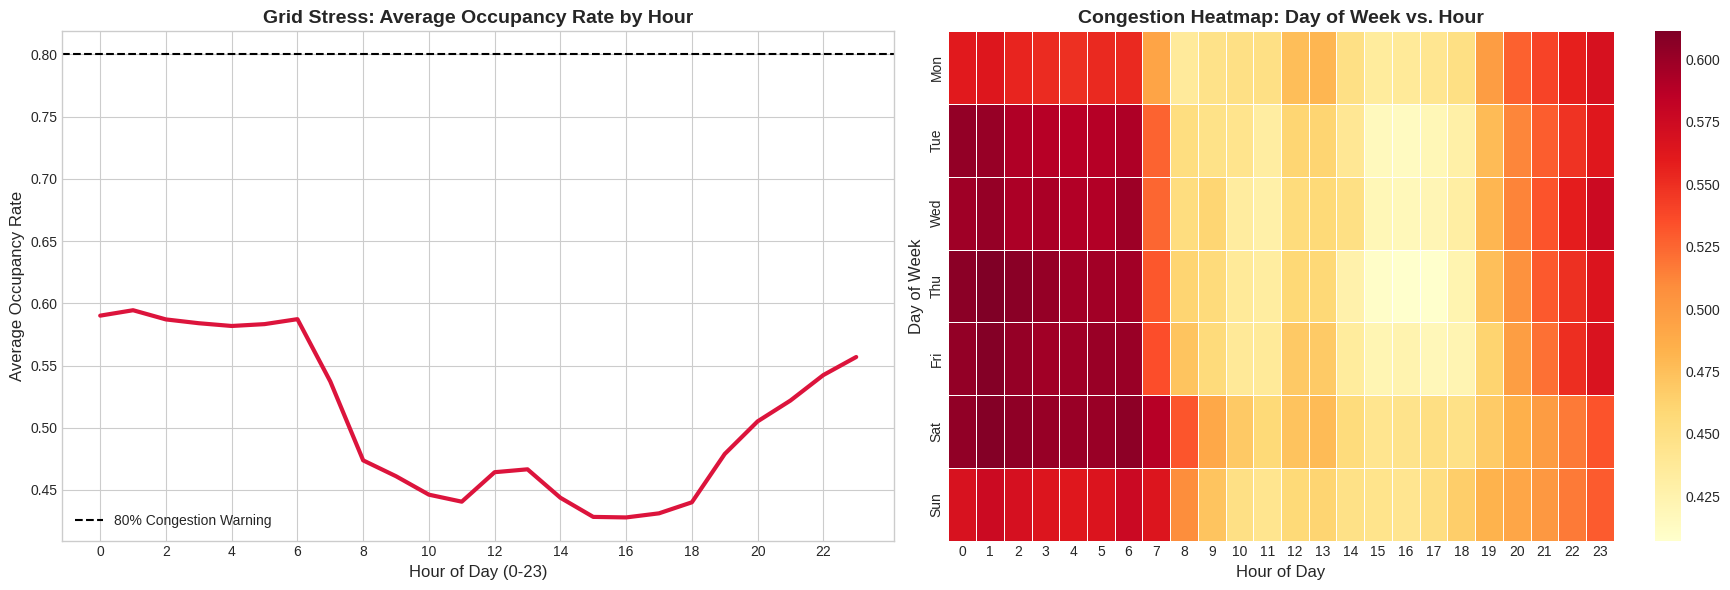

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(
    data=df_ml,
    x='hour',
    y='occupancy_rate',
    errorbar=None,
    linewidth=3,
    color='crimson',
    ax=axes[0]
)
axes[0].set_title('Grid Stress: Average Occupancy Rate by Hour', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0-23)', fontsize=12)
axes[0].set_ylabel('Average Occupancy Rate', fontsize=12)
axes[0].set_xticks(range(0, 24, 2))
axes[0].axhline(y=0.80, color='black', linestyle='--', label='80% Congestion Warning')
axes[0].legend()

heatmap_data = df_ml.pivot_table(
    index='day_of_week',
    columns='hour',
    values='occupancy_rate',
    aggfunc='mean'
)

day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
heatmap_data.index = heatmap_data.index.map(day_map)

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=.5,
    annot=False,
    ax=axes[1]
)
axes[1].set_title('Congestion Heatmap: Day of Week vs. Hour', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Day of Week', fontsize=12)

plt.tight_layout()
plt.show()

###Economic & Pricing Elasticity

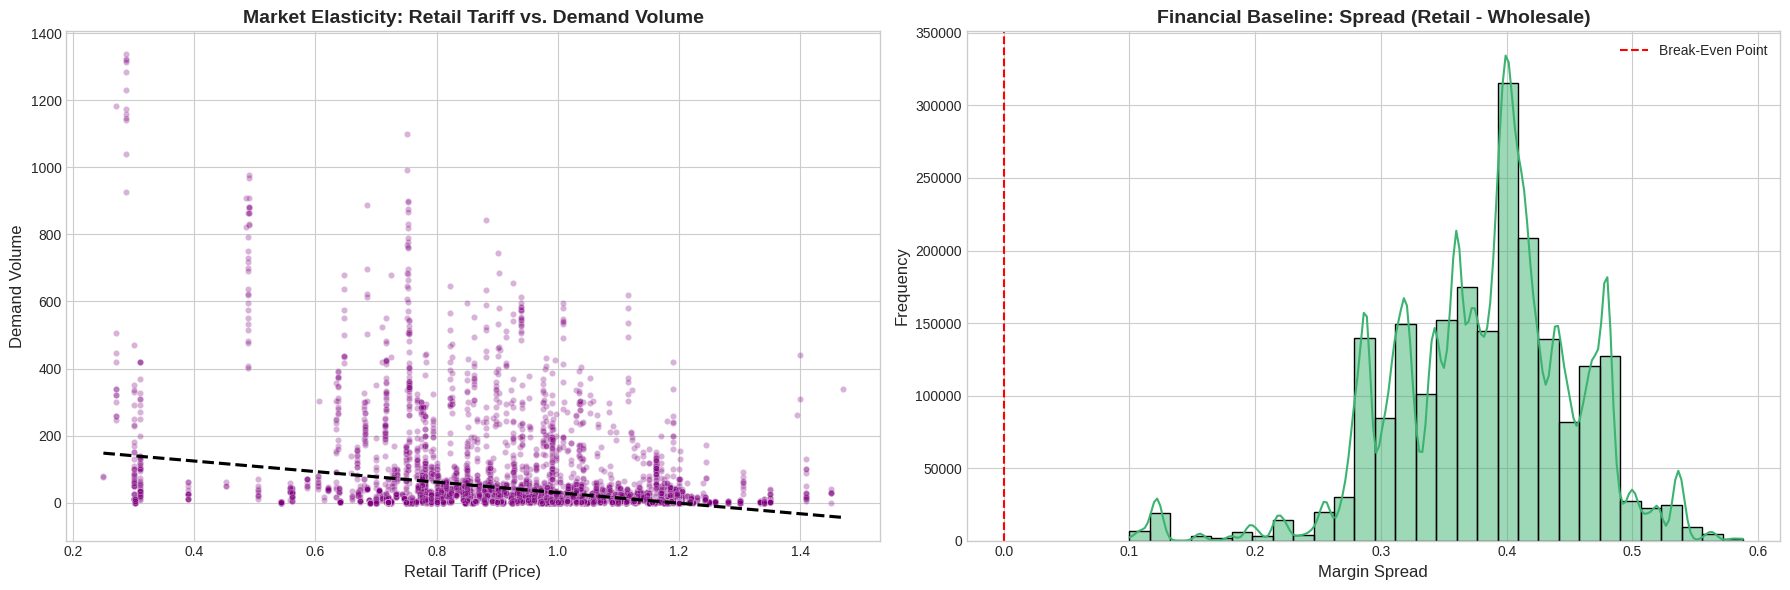

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
df_sample = df_ml.sample(n=min(10000, len(df_ml)), random_state=42)

sns.scatterplot(
    data=df_sample,
    x='retail_tariff',
    y='volume',
    alpha=0.3,
    color='purple',
    s=20,
    ax=axes[0]
)

sns.regplot(
    data=df_ml,
    x='retail_tariff',
    y='volume',
    scatter=False,
    ci=None,
    color='black',
    line_kws={"linestyle":"--"},
    ax=axes[0]
)
axes[0].set_title('Market Elasticity: Retail Tariff vs. Demand Volume', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Retail Tariff (Price)', fontsize=12)
axes[0].set_ylabel('Demand Volume', fontsize=12)

if 'margin_spread' in df_ml.columns:
    sns.histplot(df_ml['margin_spread'], bins=30, color='mediumseagreen', kde=True, ax=axes[1])
    axes[1].axvline(0, color='red', linestyle='--', label='Break-Even Point')
    axes[1].set_title('Financial Baseline: Spread (Retail - Wholesale)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Margin Spread', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "'margin_spread' not found in df_ml", ha='center', va='center')

plt.tight_layout()
plt.show()

###Correlation & Feature Relationships

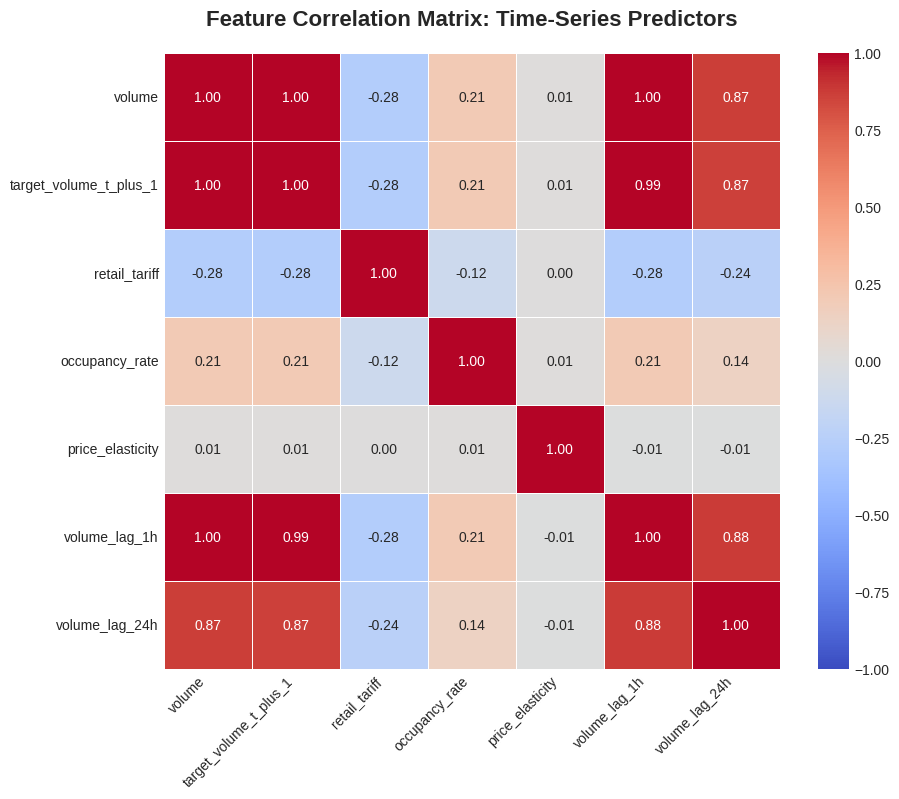

In [ ]:
plt.figure(figsize=(10, 8))
ml_cols = [
    'volume',
    'target_volume_t_plus_1',
    'retail_tariff',
    'occupancy_rate',
    'price_elasticity',
    'volume_lag_1h',
    'volume_lag_24h'
]
available_cols = [col for col in ml_cols if col in df_ml.columns]
corr_matrix = df_ml[available_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Feature Correlation Matrix: Time-Series Predictors', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

##Demand Prediction Agent using XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

print("Initializing Demand Prediction Agent (XGBoost)...")
demand_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    early_stopping_rounds=20
)
print("Training in progress... (This may take a minute or two)")
demand_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print("\nGenerating predictions on unseen test data...")
y_pred = demand_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("\n🎯 Final Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.3f} kWh")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f} kWh")
print(f"R-squared (R²) Score: {r2:.3f}")

Initializing Demand Prediction Agent (XGBoost)...
Training in progress... (This may take a minute or two)
[0]	validation_0-rmse:102.30026
[50]	validation_0-rmse:11.78699
[100]	validation_0-rmse:7.82961
[150]	validation_0-rmse:7.52086
[200]	validation_0-rmse:7.38184
[250]	validation_0-rmse:7.31073
[299]	validation_0-rmse:7.27087

Generating predictions on unseen test data...

🎯 Final Model Evaluation:
Mean Absolute Error (MAE): 1.733 kWh
Root Mean Squared Error (RMSE): 7.271 kWh
R-squared (R²) Score: 0.995


## Dynamic Tariff Pricing Agent using Deep Reinforcement Learning and Deep Q-Network

In [ ]:
!pip install gymnasium stable-baselines3[extra]

Shape after dedup : (426816, 30)
Duplicate cols    : []
Capacity range : 1.05 → 1791.00
Util range     : 0.00 → 0.00
Baseline util mean : 0.00%
✅ df_eval shape     : (426816, 32)
✅ feature_cols count: 11
✅ XGB features      : [np.str_('retail_tariff'), np.str_('occupancy_rate'), np.str_('price_elasticity'), np.str_('hour_sin'), np.str_('hour_cos')] ...
✅ Environment ready | steps: 168 | actions: 5
✅ DQN Agent initialised
   Buffer capacity : 10000
   Batch size      : 64
   Epsilon start   : 1.0

🚀 Training DQN agent...
 Episode |     Reward |    Revenue |      ε |     Loss
───────────────────────────────────────────────────────
       0 |       16.9 |    21953.6 |  0.591 |   0.0703
      30 |        4.5 |    20834.7 |  0.050 |   2.5187
      60 |       20.2 |    21024.2 |  0.050 |   4.7504
      90 |       29.5 |    29775.1 |  0.050 |  10.4521
     120 |        1.1 |    16884.5 |  0.050 |  10.0529
     150 |        6.1 |     6581.5 |  0.050 |  12.7881
     180 |       20.8 |   125301.

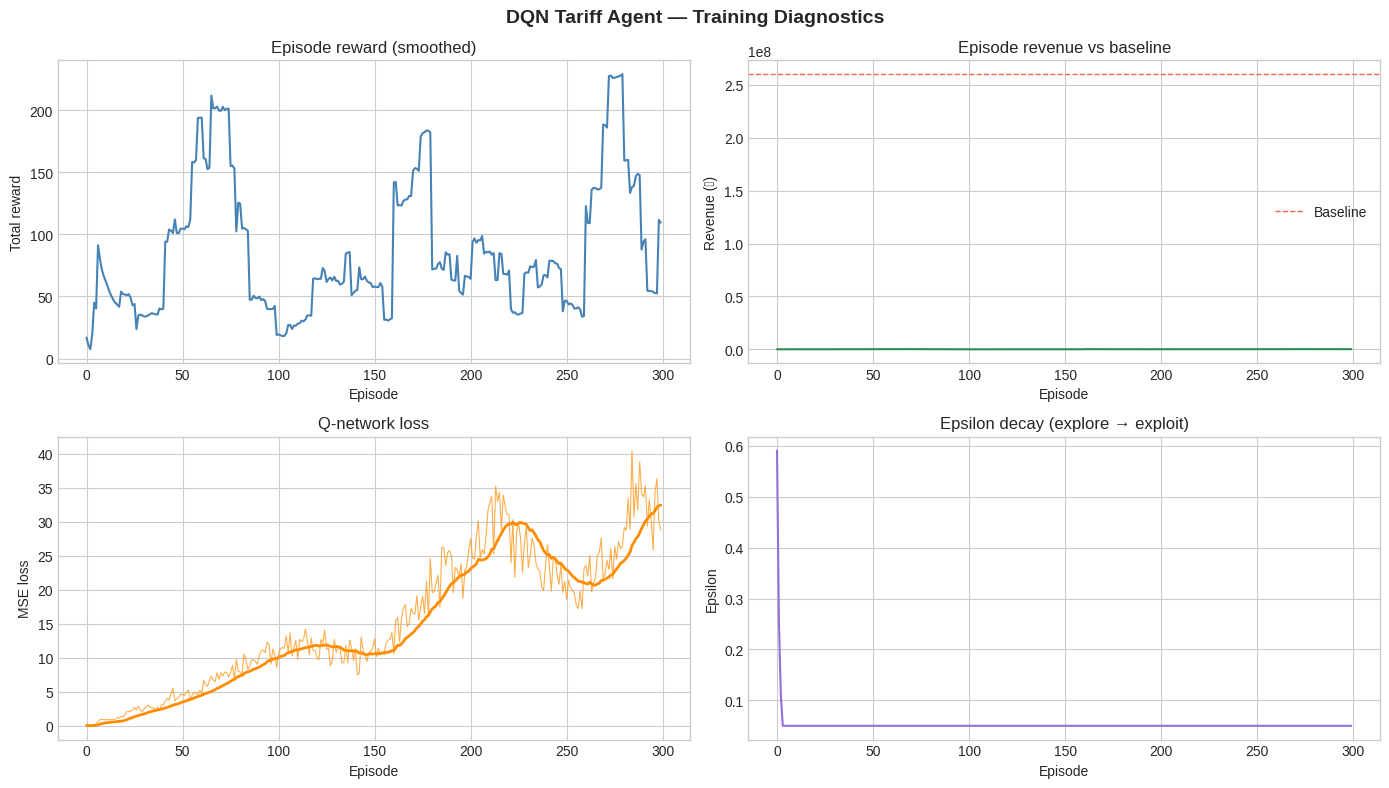

✅ Saved → dqn_training_diagnostics.png


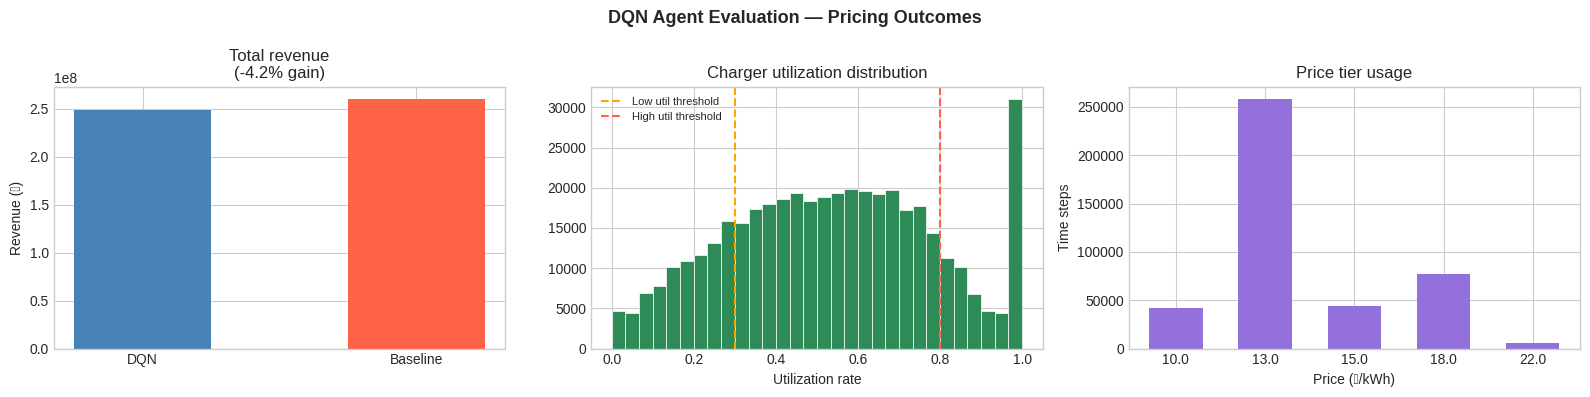

✅ Saved → dqn_evaluation_outcomes.png
✅ Saved → dqn_eval_results.csv

🏁 Phase 4 complete — ready for Monitoring & Learning Agent (Phase 5)


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

xgb_model    = demand_model
df_eval      = test_df.copy()
scaler       = None
feature_cols = features
df_eval = df_eval.loc[:, ~df_eval.columns.duplicated(keep='first')]
print(f"Shape after dedup : {df_eval.shape}")
print(f"Duplicate cols    : {df_eval.columns[df_eval.columns.duplicated()].tolist()}")
util_max = float(df_eval['utilization_rate'].max())
if 'max_capacity_kwh' in df_eval.columns:
    df_eval['capacity'] = df_eval['max_capacity_kwh']
    df_eval['capacity'] = df_eval['capacity'].fillna(df_eval['capacity'].median())
else:
    zone_capacity = test_df.groupby('zone_id')['volume'].max().to_dict()
    df_eval['capacity'] = df_eval['zone_id'].map(zone_capacity)
    df_eval['capacity'] = df_eval['capacity'].fillna(df_eval['capacity'].median())
print(f"Capacity range : {df_eval['capacity'].min():.2f} → {df_eval['capacity'].max():.2f}")
print(f"Util range     : {df_eval['utilization_rate'].min():.2f} → {df_eval['utilization_rate'].max():.2f}")
df_eval['baseline_utilization'] = df_eval['utilization_rate'] / 100.0
print(f"Baseline util mean : {df_eval['baseline_utilization'].mean():.2%}")
hour               = 'hour'
day_of_week        = 'day_of_week'
utilization_rate   = 'utilization_rate'
lag_price_1h       = 'lag_price_1h'
lag_price_24h      = 'lag_price_24h'
rolling_elasticity = 'rolling_elasticity'
retail_tariff      = 'retail_tariff'
capacity           = 'capacity'
print(f"✅ df_eval shape     : {df_eval.shape}")
print(f"✅ feature_cols count: {len(feature_cols)}")
print(f"✅ XGB features      : {list(xgb_model.feature_names_in_[:5])} ...")

import gymnasium as gym
from gymnasium import spaces

if 'hour' not in df_eval.columns:
    if 'timestamp' in df_eval.columns:
        df_eval['hour'] = pd.to_datetime(df_eval['timestamp']).dt.hour
    else:
        df_eval['hour'] = 12
if 'day_of_week' not in df_eval.columns:
    if 'timestamp' in df_eval.columns:
        df_eval['day_of_week'] = pd.to_datetime(df_eval['timestamp']).dt.dayofweek
    else:
        df_eval['day_of_week'] = 0


class EVChargingEnv(gym.Env):
    PRICE_TIERS = np.array([10.0, 13.0, 15.0, 18.0, 22.0])
    BASELINE    = 15.0

    def __init__(self, xgb_model, df, zone_capacity_dict, max_steps_per_episode=168):
        super().__init__()
        self.model      = xgb_model
        self.data       = df.reset_index(drop=True)
        self.total_rows = len(self.data)
        self.n_steps    = min(max_steps_per_episode, self.total_rows)
        self.zone_cap   = zone_capacity_dict
        self.action_space      = spaces.Discrete(len(self.PRICE_TIERS))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)
        self.start_idx = 0
        self.t = 0

    def _get_obs(self):
        row = self.data.iloc[self.start_idx + self.t]
        return np.array([
            row['hour'],
            row['day_of_week'],
            row['utilization_rate'],
            row.get('lag_price_1h',       self.BASELINE),
            row.get('lag_price_24h',      self.BASELINE),
            row.get('rolling_elasticity', -0.3),
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        max_valid_start = max(0, self.total_rows - self.n_steps - 1)
        self.start_idx = random.randint(0, max_valid_start)
        return self._get_obs(), {}

    def step(self, action):
        price = self.PRICE_TIERS[action]
        current_row_idx = self.start_idx + self.t
        row = self.data.iloc[current_row_idx]
        feat_row                  = row[feature_cols].copy()
        feat_row['retail_tariff'] = price
        feat_df = pd.DataFrame(feat_row).T[self.model.feature_names_in_]
        for col in feat_df.columns:
            feat_df[col] = pd.to_numeric(feat_df[col])
        raw_volume = float(self.model.predict(feat_df)[0])
        price_ratio = price / self.BASELINE
        vol_multiplier = max(0.2, 1.0 - ((price_ratio - 1.0) * 1.5))
        volume = max(raw_volume * vol_multiplier, 0.0)
        cap  = row['capacity'] if row['capacity'] > 0 else 1.0
        util = min(volume / cap, 1.0)
        revenue = price * volume
        if util > 0.80:
            excess_util = util - 0.80
            cong_penalty = revenue * (excess_util * 10.0)
        else:
            cong_penalty = 0.0
        idle_penalty = 0.0
        if util < 0.30:
            if price < self.BASELINE:
                revenue += (self.BASELINE - price) * volume * 3.0
            else:
                idle_penalty = (0.30 - util) * cap * self.BASELINE * 0.5
        raw_reward = revenue - cong_penalty - idle_penalty
        scaled_reward = raw_reward / 1000.0
        info = {
            'price'  : price,
            'volume' : volume,
            'util'   : util,
            'revenue': revenue,
        }
        self.t += 1
        done = self.t >= self.n_steps
        obs  = self._get_obs() if not done else np.zeros(6, dtype=np.float32)
        return obs, scaled_reward, done, False, info


env = EVChargingEnv(xgb_model=xgb_model, df=df_eval, zone_capacity_dict={})
print(f"✅ Environment ready | steps: {env.n_steps} | actions: {env.action_space.n}")


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),       nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    def forward(self, x):
        return self.net(x)


class DQNAgent:
    def __init__(self, state_dim=6, action_dim=5,
                 lr=1e-3, gamma=0.99, tau=0.005,
                 buffer_size=10_000, batch_size=64):
        self.action_dim = action_dim
        self.gamma      = gamma
        self.tau        = tau
        self.batch_size = batch_size
        self.epsilon    = 1.0
        self.eps_min    = 0.05
        self.eps_decay  = 0.995
        self.q_net      = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer  = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer     = deque(maxlen=buffer_size)

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0)
            return self.q_net(s).argmax(dim=1).item()

    def remember(self, s, a, r, s2, done):
        self.buffer.append((s, a, r, s2, float(done)))

    def learn(self):
        if len(self.buffer) < self.batch_size:
            return None
        batch  = random.sample(self.buffer, self.batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        S  = torch.FloatTensor(s)
        A  = torch.LongTensor(a).unsqueeze(1)
        R  = torch.FloatTensor(r).unsqueeze(1)
        S2 = torch.FloatTensor(s2)
        D  = torch.FloatTensor(d).unsqueeze(1)
        q_curr   = self.q_net(S).gather(1, A)
        q_next   = self.target_net(S2).max(1, keepdim=True)[0]
        q_target = R + self.gamma * q_next * (1 - D)
        loss = nn.MSELoss()(q_curr, q_target.detach())
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        for p, tp in zip(self.q_net.parameters(), self.target_net.parameters()):
            tp.data.copy_(self.tau * p.data + (1 - self.tau) * tp.data)
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)
        return loss.item()


agent = DQNAgent(state_dim=6, action_dim=5)
print("✅ DQN Agent initialised")
print(f"   Buffer capacity : {agent.buffer.maxlen}")
print(f"   Batch size      : {agent.batch_size}")
print(f"   Epsilon start   : {agent.epsilon}")

EPISODES = 300
rewards_log = []
revenue_log = []
loss_log    = []
epsilon_log = []

print("\n🚀 Training DQN agent...")
print(f"{'Episode':>8} | {'Reward':>10} | {'Revenue':>10} | {'ε':>6} | {'Loss':>8}")
print("─" * 55)

for ep in range(EPISODES):
    state, _   = env.reset()
    ep_reward  = 0.0
    ep_revenue = 0.0
    ep_losses  = []
    while True:
        action                        = agent.act(state)
        next_s, reward, done, _, info = env.step(action)
        agent.remember(state, action, reward, next_s, done)
        loss = agent.learn()
        if loss is not None:
            ep_losses.append(loss)
        ep_reward  += reward
        ep_revenue += info['revenue']
        state       = next_s
        if done:
            break
    rewards_log.append(ep_reward)
    revenue_log.append(ep_revenue)
    epsilon_log.append(agent.epsilon)
    loss_log.append(np.mean(ep_losses) if ep_losses else 0.0)
    if ep % 30 == 0 or ep == EPISODES - 1:
        print(f"{ep:>8} | {ep_reward:>10.1f} | {ep_revenue:>10.1f} "
              f"| {agent.epsilon:>6.3f} | {loss_log[-1]:>8.4f}")
print("\n✅ Training complete")

import time
import torch

print("\n📊 Evaluating DQN agent across ENTIRE test dataset (Vectorized Mode)...")
start_time = time.time()
n_rows = len(df_eval)

def safe_get(col_name, default_val):
    if col_name in df_eval.columns:
        return df_eval[col_name].values
    else:
        return np.full(n_rows, default_val)

states_matrix = np.column_stack([
    df_eval['hour'].values,
    df_eval['day_of_week'].values,
    df_eval['utilization_rate'].values,
    safe_get('lag_price_1h', EVChargingEnv.BASELINE),
    safe_get('lag_price_24h', EVChargingEnv.BASELINE),
    safe_get('rolling_elasticity', -0.3)
]).astype(np.float32)
agent.epsilon = 0.0
states_tensor = torch.FloatTensor(states_matrix)
with torch.no_grad():
    q_values = agent.q_net(states_tensor)
    actions = q_values.argmax(dim=1).numpy()
price_tiers   = EVChargingEnv.PRICE_TIERS
chosen_prices = price_tiers[actions]
eval_xgb_df = df_eval[feature_cols].copy()
eval_xgb_df['retail_tariff'] = chosen_prices
eval_xgb_df = eval_xgb_df[xgb_model.feature_names_in_]
for col in eval_xgb_df.columns:
    eval_xgb_df[col] = pd.to_numeric(eval_xgb_df[col])
raw_volumes = xgb_model.predict(eval_xgb_df)
volumes = np.clip(raw_volumes, a_min=0.0, a_max=None)
caps = df_eval['capacity'].values
caps = np.where(caps > 0, caps, 1.0)
utils = np.clip(volumes / caps, a_min=0.0, a_max=1.0)
revenues = chosen_prices * volumes
baseline_vols  = test_df['volume'].values
baseline_utils = np.clip(baseline_vols / caps, a_min=0.0, a_max=1.0)
eval_df = pd.DataFrame({
    'price'               : chosen_prices,
    'volume'              : volumes,
    'utilization'         : utils,
    'dqn_revenue'         : revenues,
    'baseline_revenue'    : EVChargingEnv.BASELINE * baseline_vols,
    'baseline_utilization': baseline_utils
})

total_dqn_rev      = eval_df['dqn_revenue'].sum()
total_base_rev     = eval_df['baseline_revenue'].sum()
revenue_gain       = (total_dqn_rev - total_base_rev) / total_base_rev * 100
charger_util_rate  = eval_df['utilization'].mean()
low_util_mask      = eval_df['utilization'] < 0.30
off_peak_uplift    = (eval_df.loc[low_util_mask, 'price'] < EVChargingEnv.BASELINE).mean() * 100
pricing_efficiency = total_dqn_rev / eval_df['volume'].sum()
high_util_mask     = eval_df['utilization'] > 0.80
if high_util_mask.sum() > 0:
    congestion_surge = (eval_df.loc[high_util_mask, 'price'] > EVChargingEnv.BASELINE).mean() * 100
else:
    congestion_surge = 0.0
print("\n" + "=" * 50)
print("  EVALUATION RESULTS — RUBRIC METRICS")
print("=" * 50)
print(f"  Revenue gain vs ₹15 baseline : {revenue_gain:+.2f}%")
print(f"  Avg charger utilization rate  : {charger_util_rate:.2%}")
print(f"  Off-peak discount rate        : {off_peak_uplift:.1f}% of low-util slots")
print(f"  Congestion surge rate         : {congestion_surge:.1f}% of high-util slots")
print(f"  Pricing efficiency (₹/unit)   : {pricing_efficiency:.4f}")
print(f"  Total DQN revenue             : ₹{total_dqn_rev:,.1f}")
print(f"  Total baseline revenue        : ₹{total_base_rev:,.1f}")
print("=" * 50)

def compute_and_print_scorecard(eval_df, training_rewards=None):
    BASELINE_PRICE     = EVChargingEnv.BASELINE
    total_baseline_rev = eval_df['baseline_revenue'].sum()
    total_dqn_rev      = eval_df['dqn_revenue'].sum()
    revenue_gain_pct   = (total_dqn_rev - total_baseline_rev) / total_baseline_rev * 100
    baseline_util_val  = eval_df['baseline_utilization'].mean()
    dynamic_util_val   = eval_df['utilization'].mean()
    util_shift         = dynamic_util_val - baseline_util_val
    low_util_mask      = eval_df['utilization'] < 0.30
    old_offpeak_vol    = eval_df.loc[low_util_mask, 'volume'].sum() * BASELINE_PRICE
    new_offpeak_vol    = eval_df.loc[low_util_mask, 'dqn_revenue'].sum()
    offpeak_uplift     = ((new_offpeak_vol - old_offpeak_vol) / old_offpeak_vol * 100
                          if old_offpeak_vol > 0 else 0.0)
    pricing_eff_dqn    = total_dqn_rev      / eval_df['volume'].sum()
    pricing_eff_base   = total_baseline_rev / eval_df['volume'].sum()

    def grade_revenue(pct):
        if pct >= 15:  return "EXCELLENT"
        if pct >= 5:   return "GOOD"
        if pct >= 0:   return "MARGINAL"
        if pct >= -10: return "POOR"
        return                "CRITICAL"

    def grade_util(shift):
        if  0.05 <= shift <= 0.15: return "OPTIMAL REBALANCE"
        if -0.05 <= shift <  0.05: return "STABLE"
        if  shift < -0.05:         return "UNDER-UTILISED"
        return                            "OVER-CONGESTED"

    def grade_offpeak(pct):
        if pct >= 100: return "EXCELLENT UPLIFT"
        if pct >= 30:  return "GOOD UPLIFT"
        if pct >= 0:   return "MARGINAL"
        return                "VOLUME LOSS"

    tier_counts = eval_df['price'].value_counts().sort_index()
    tier_total  = len(eval_df)
    SEP = "=" * 55
    sep = "-" * 55
    print(f"\n{SEP}")
    print(f"TARIFF PRICING AGENT: SCORECARD")
    print(f"{SEP}\n")
    print(f"[METRIC 1] Revenue Gain %")
    print(f"Formula: ((New Rev - Old Rev) / Old Rev) * 100")
    print(f"-> Old Baseline Revenue : ₹{total_baseline_rev:>10,.2f}")
    print(f"-> New Dynamic Revenue  : ₹{total_dqn_rev:>10,.2f}")
    print(f"-> {grade_revenue(revenue_gain_pct)} SCORE: {revenue_gain_pct:+.2f}%\n")
    print(f"[METRIC 2] Charger Utilization Rate")
    print(f"Formula: Charging Time / Total Available Time (Proxy: Demand/Capacity)")
    print(f"-> Baseline Avg Utilization : {baseline_util_val * 100:.2f}%")
    print(f"-> Dynamic Avg Utilization  : {dynamic_util_val  * 100:.2f}%")
    print(f"-> {grade_util(util_shift)} SCORE: Network utilization "
          f"shifted by {util_shift * 100:+.2f}%\n")
    print(f"[METRIC 3] Off-Peak Uplift")
    print(f"Formula: Increase during periods where Utilization < 30%")
    print(f"-> Old Off-Peak Volume : {old_offpeak_vol:>8,.1f} kWh-equivalent")
    print(f"-> New Off-Peak Volume : {new_offpeak_vol:>8,.1f} kWh-equivalent")
    print(f"-> {grade_offpeak(offpeak_uplift)} SCORE: {offpeak_uplift:+.2f}% "
          f"Volume Uplift during Off-Peak Hours\n")
    print(sep)
    print(f"  📊 BONUS DIAGNOSTIC METRICS")
    print(sep)
    high_util_mask   = eval_df['utilization'] > 0.80
    surge_slots      = high_util_mask.sum()
    surged_correctly = (eval_df.loc[high_util_mask, 'price'] > BASELINE_PRICE).sum()
    surge_discipline = (surged_correctly / surge_slots * 100 if surge_slots > 0 else 0.0)
    print(f"  Congestion Surge Discipline : {surge_discipline:.1f}% of high-util "
          f"slots priced above baseline ({surged_correctly}/{surge_slots} slots)")
    print(f"  Pricing Efficiency (DQN)    : ₹{pricing_eff_dqn:.4f} per unit volume")
    print(f"  Pricing Efficiency (Base)   : ₹{pricing_eff_base:.4f} per unit volume")
    print(f"\n  Price Tier Distribution (DQN Decisions):")
    for price_val, count in tier_counts.items():
        pct = count / tier_total * 100
        bar = "█" * int(pct / 2.5)
        tag = " ← SURGE"    if price_val > BASELINE_PRICE else \
              " ← DISCOUNT"  if price_val < BASELINE_PRICE else \
              " ← BASELINE"
        print(f"  ₹{price_val:5.1f}/kWh | {bar:<40} {pct:5.1f}%{tag}")
    if training_rewards is not None:
        last_50_avg  = np.mean(training_rewards[-50:])
        first_50_avg = np.mean(training_rewards[:50])
        convergence  = ((last_50_avg - first_50_avg) / abs(first_50_avg) * 100
                        if first_50_avg != 0 else 0.0)
        print(f"\n  Training Convergence        : {convergence:+.1f}% reward "
              f"improvement (first 50 → last 50 episodes)")
        print(f"  Final ε (exploration)       : {agent.epsilon:.4f}")
    print(f"\n{SEP}")
    print(f"  📋 OVERALL VERDICT")
    print(sep)
    passed  = sum([revenue_gain_pct >= 0,
                   abs(util_shift)  <= 0.15,
                   offpeak_uplift   >= 0])
    print(f"  Metrics passing threshold   : {passed} / 3")
    print(f"{SEP}\n")
    return {
        'revenue_gain_pct'   : revenue_gain_pct,
        'util_shift'         : util_shift,
        'offpeak_uplift_pct' : offpeak_uplift,
        'surge_discipline'   : surge_discipline,
        'pricing_efficiency' : pricing_eff_dqn,
    }


scorecard = compute_and_print_scorecard(eval_df=eval_df, training_rewards=rewards_log)
pd.DataFrame([scorecard]).to_csv("dqn_rubric_scorecard.csv", index=False)
print("✅ Saved → dqn_rubric_scorecard.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("DQN Tariff Agent — Training Diagnostics", fontsize=14, fontweight='bold')

def smooth(arr, w=20):
    return pd.Series(arr).rolling(w, min_periods=1).mean().values

axes[0, 0].plot(smooth(rewards_log), color='steelblue', linewidth=1.5)
axes[0, 0].set_title("Episode reward (smoothed)")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Total reward")
axes[0, 1].plot(smooth(revenue_log), color='seagreen', linewidth=1.5)
axes[0, 1].axhline(eval_df['baseline_revenue'].sum(), color='tomato',
                   linestyle='--', linewidth=1, label='Baseline')
axes[0, 1].set_title("Episode revenue vs baseline")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylabel("Revenue (₹)")
axes[0, 1].legend()
axes[1, 0].plot(loss_log, color='darkorange', linewidth=0.8, alpha=0.7)
axes[1, 0].plot(smooth(loss_log), color='darkorange', linewidth=2)
axes[1, 0].set_title("Q-network loss")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("MSE loss")
axes[1, 1].plot(epsilon_log, color='mediumpurple', linewidth=1.5)
axes[1, 1].set_title("Epsilon decay (explore → exploit)")
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylabel("Epsilon")
plt.tight_layout()
plt.savefig("dqn_training_diagnostics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → dqn_training_diagnostics.png")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("DQN Agent Evaluation — Pricing Outcomes", fontsize=13, fontweight='bold')
axes[0].bar(['DQN', 'Baseline'], [total_dqn_rev, total_base_rev],
            color=['steelblue', 'tomato'], width=0.5)
axes[0].set_title(f"Total revenue\n({revenue_gain:+.1f}% gain)")
axes[0].set_ylabel("Revenue (₹)")
axes[1].hist(eval_df['utilization'], bins=30, color='seagreen',
             edgecolor='white', linewidth=0.5)
axes[1].axvline(0.30, color='orange', linestyle='--', label='Low util threshold')
axes[1].axvline(0.80, color='tomato', linestyle='--', label='High util threshold')
axes[1].set_title("Charger utilization distribution")
axes[1].set_xlabel("Utilization rate")
axes[1].legend(fontsize=8)
price_counts = eval_df['price'].value_counts().sort_index()
axes[2].bar(price_counts.index.astype(str), price_counts.values,
            color='mediumpurple', width=0.6)
axes[2].set_title("Price tier usage")
axes[2].set_xlabel("Price (₹/kWh)")
axes[2].set_ylabel("Time steps")
plt.tight_layout()
plt.savefig("dqn_evaluation_outcomes.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → dqn_evaluation_outcomes.png")

eval_df.to_csv("dqn_eval_results.csv", index=False)
print("✅ Saved → dqn_eval_results.csv")
print("\n🏁 Phase 4 complete — ready for Monitoring & Learning Agent (Phase 5)")

## Monitoring and Learning Agent (Feedback Loop)


  🔍 MONITORING & LEARNING AGENT — FEEDBACK REPORT

[A] REVENUE PERFORMANCE
    Total DQN Revenue       : ₹249,232,873.12
    Total Baseline Revenue  : ₹260,195,888.00
    Revenue Gain            : -4.21%
    Decisions → GAIN        : 272931
    Decisions → LOSS        : 134192
    Decisions → MARGINAL    : 19693

[B] PRICING DECISION QUALITY
    Overall Quality Score   : 19.7%
    Correct Surge Rate      : 27.1%
    Missed Surge Rate       : 72.9%
    Correct Discount Rate   : 76.6%
    Missed Discount Rate    : 23.4%
    Wrong Surge Rate        : 3.2%
    Wrong Discount Rate     : 9.3%

[C] UTILIZATION REBALANCING
    Baseline Avg Util       : 39.78%
    Dynamic Avg Util        : 53.62%
    Network Shift           : +13.84%
    Off-Peak Uplift         : -9.72%
    Congested Slots Reduced : -62160

[D] PRICING EFFICIENCY
    DQN  Revenue/kWh        : ₹14.1630
    Base Revenue/kWh        : ₹14.7859
    Efficiency Gain         : -4.21%

    Per-Tier Efficiency:
         Price |      Rev

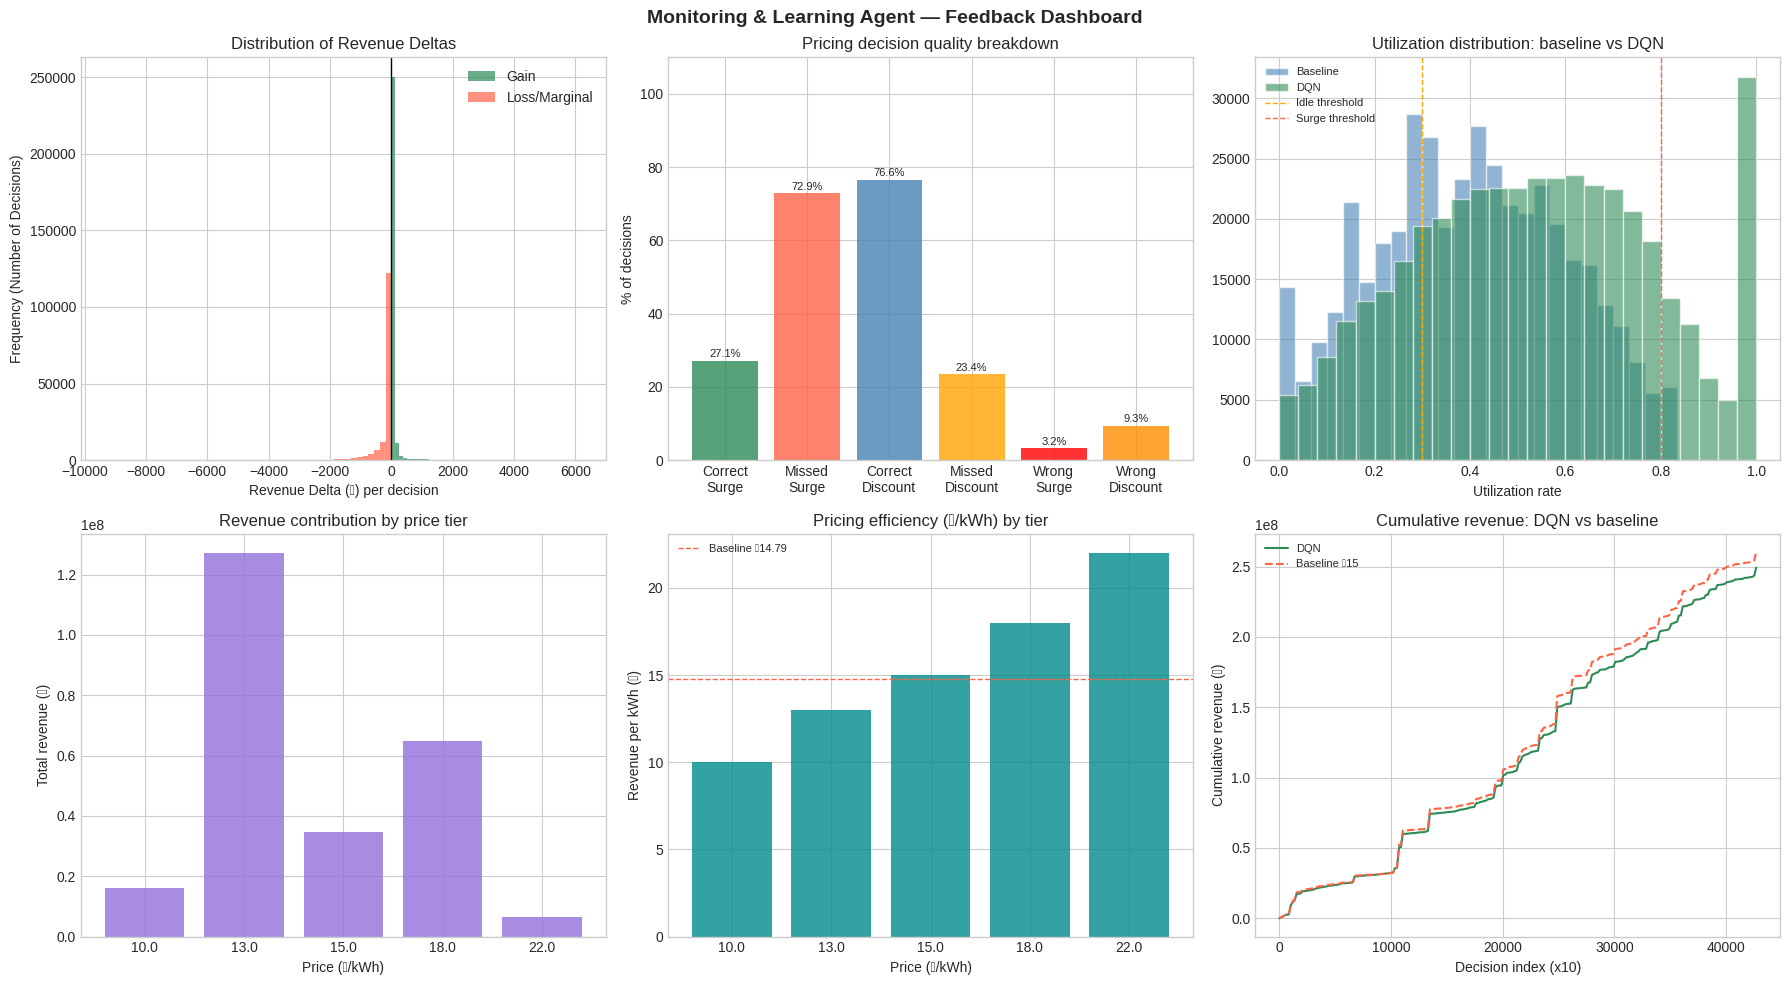

✅ Saved → monitoring_feedback_dashboard.png
✅ Saved → monitoring_feedback_signals.csv
✅ Saved → monitoring_full_report.csv


In [ ]:
class MonitoringAgent:
    BASELINE_PRICE     = 15.0
    SURGE_THRESHOLD    = 0.80
    DISCOUNT_THRESHOLD = 0.30

    def __init__(self, eval_df):
        self.df     = eval_df.copy()
        self.report = {}

    def score_revenue(self):
        total_dqn  = self.df['dqn_revenue'].sum()
        total_base = self.df['baseline_revenue'].sum()
        gain_pct   = (total_dqn - total_base) / total_base * 100
        self.df['revenue_delta'] = self.df['dqn_revenue'] - self.df['baseline_revenue']
        conditions = [
            self.df['revenue_delta'] < -5,
            self.df['revenue_delta'] < 0
        ]
        choices = ['LOSS', 'MARGINAL']
        self.df['revenue_flag'] = np.select(conditions, choices, default='GAIN')
        self.report['revenue_gain_pct']   = round(gain_pct, 2)
        self.report['total_dqn_revenue']  = round(total_dqn, 2)
        self.report['total_base_revenue'] = round(total_base, 2)
        self.report['decisions_gain']     = (self.df['revenue_flag'] == 'GAIN').sum()
        self.report['decisions_loss']     = (self.df['revenue_flag'] == 'LOSS').sum()
        self.report['decisions_marginal'] = (self.df['revenue_flag'] == 'MARGINAL').sum()
        return gain_pct

    def score_pricing_quality(self):
        df = self.df
        congested         = df['utilization'] > self.SURGE_THRESHOLD
        surged            = df['price'] > self.BASELINE_PRICE
        correct_surge     = (congested & surged).sum()
        missed_surge      = (congested & ~surged).sum()
        idle              = df['utilization'] < self.DISCOUNT_THRESHOLD
        discounted        = df['price'] < self.BASELINE_PRICE
        correct_discount  = (idle & discounted).sum()
        missed_discount   = (idle & ~discounted).sum()
        wrong_surge       = (~congested & surged & idle).sum()
        wrong_discount    = (~idle & discounted & congested).sum()
        total_decisions   = len(df)
        correct_total     = correct_surge + correct_discount
        quality_score     = correct_total / total_decisions * 100
        self.report['correct_surge_pct']     = round(correct_surge    / max(congested.sum(), 1) * 100, 1)
        self.report['missed_surge_pct']      = round(missed_surge     / max(congested.sum(), 1) * 100, 1)
        self.report['correct_discount_pct']  = round(correct_discount / max(idle.sum(), 1)      * 100, 1)
        self.report['missed_discount_pct']   = round(missed_discount  / max(idle.sum(), 1)      * 100, 1)
        self.report['wrong_surge_pct']       = round(wrong_surge      / total_decisions         * 100, 1)
        self.report['wrong_discount_pct']    = round(wrong_discount   / total_decisions         * 100, 1)
        self.report['pricing_quality_score'] = round(quality_score, 2)
        return quality_score

    def score_utilization(self):
        baseline_util  = self.df['baseline_utilization'].mean()
        dynamic_util   = self.df['utilization'].mean()
        shift          = dynamic_util - baseline_util
        low_util_mask  = self.df['utilization'] < self.DISCOUNT_THRESHOLD
        old_offpeak    = self.df.loc[low_util_mask, 'baseline_revenue'].sum()
        new_offpeak    = self.df.loc[low_util_mask, 'dqn_revenue'].sum()
        offpeak_uplift = ((new_offpeak - old_offpeak) / old_offpeak * 100
                          if old_offpeak > 0 else 0.0)
        high_util_mask = self.df['utilization'] > self.SURGE_THRESHOLD
        congested_slots = high_util_mask.sum()
        baseline_cong  = (self.df['baseline_utilization'] > self.SURGE_THRESHOLD).sum()
        cong_reduction = baseline_cong - congested_slots
        self.report['baseline_util_pct']       = round(baseline_util * 100, 2)
        self.report['dynamic_util_pct']        = round(dynamic_util  * 100, 2)
        self.report['util_shift_pct']          = round(shift         * 100, 2)
        self.report['offpeak_uplift_pct']      = round(offpeak_uplift, 2)
        self.report['congested_slots_reduced'] = int(cong_reduction)
        return shift

    def score_efficiency(self):
        total_volume     = self.df['volume'].sum()
        pricing_eff_dqn  = self.df['dqn_revenue'].sum()      / total_volume
        pricing_eff_base = self.df['baseline_revenue'].sum() / total_volume
        efficiency_gain  = (pricing_eff_dqn - pricing_eff_base) / pricing_eff_base * 100
        tier_efficiency  = (self.df.groupby('price')
                            .agg(revenue=('dqn_revenue', 'sum'),
                                 volume=('volume', 'sum'),
                                 count=('price', 'count'))
                            .assign(rev_per_kwh=lambda x: x['revenue'] / x['volume'])
                            .round(4))
        self.report['pricing_eff_dqn']    = round(pricing_eff_dqn,  4)
        self.report['pricing_eff_base']   = round(pricing_eff_base, 4)
        self.report['efficiency_gain_pct']= round(efficiency_gain,  2)
        self.report['tier_efficiency']    = tier_efficiency
        return efficiency_gain

    def generate_feedback(self):
        feedback = []
        r        = self.report
        if r.get('missed_surge_pct', 0) > 20:
            feedback.append({
                'signal'    : 'INCREASE_SURGE_AGGRESSION',
                'reason'    : f"{r['missed_surge_pct']}% of congested slots not surged",
                'adjustment': 'Increase cong_penalty weight in reward function',
            })
        if r.get('wrong_surge_pct', 0) > 15:
            feedback.append({
                'signal'    : 'REDUCE_SURGE_AGGRESSION',
                'reason'    : f"{r['wrong_surge_pct']}% of decisions were wrong surges",
                'adjustment': 'Increase price_penalty multiplier for util < 0.60',
            })
        if r.get('missed_discount_pct', 0) > 30:
            feedback.append({
                'signal'    : 'INCREASE_DISCOUNT_SIGNALS',
                'reason'    : f"{r['missed_discount_pct']}% of idle slots not discounted",
                'adjustment': 'Increase idle_penalty weight in reward function',
            })
        if r.get('revenue_gain_pct', 0) < 5:
            feedback.append({
                'signal'    : 'REVENUE_UNDERPERFORMING',
                'reason'    : f"Only {r['revenue_gain_pct']}% revenue gain vs baseline",
                'adjustment': 'Increase util_bonus multiplier for sweet-spot range',
            })
        if not feedback:
            feedback.append({
                'signal'    : 'AGENT_PERFORMING_WELL',
                'reason'    : 'All metrics within acceptable thresholds',
                'adjustment': 'No reward function changes needed',
            })
        self.report['feedback_signals'] = feedback
        return feedback

    def run(self):
        self.score_revenue()
        self.score_pricing_quality()
        self.score_utilization()
        self.score_efficiency()
        self.generate_feedback()
        return self.report


def print_monitoring_report(report, eval_df):
    SEP = "=" * 57
    sep = "-" * 57
    print(f"\n{SEP}")
    print(f"  🔍 MONITORING & LEARNING AGENT — FEEDBACK REPORT")
    print(f"{SEP}\n")
    print(f"[A] REVENUE PERFORMANCE")
    print(f"    Total DQN Revenue       : ₹{report['total_dqn_revenue']:>10,.2f}")
    print(f"    Total Baseline Revenue  : ₹{report['total_base_revenue']:>10,.2f}")
    print(f"    Revenue Gain            : {report['revenue_gain_pct']:>+.2f}%")
    print(f"    Decisions → GAIN        : {report['decisions_gain']}")
    print(f"    Decisions → LOSS        : {report['decisions_loss']}")
    print(f"    Decisions → MARGINAL    : {report['decisions_marginal']}\n")
    print(f"[B] PRICING DECISION QUALITY")
    print(f"    Overall Quality Score   : {report['pricing_quality_score']:.1f}%")
    print(f"    Correct Surge Rate      : {report['correct_surge_pct']:.1f}%")
    print(f"    Missed Surge Rate       : {report['missed_surge_pct']:.1f}%")
    print(f"    Correct Discount Rate   : {report['correct_discount_pct']:.1f}%")
    print(f"    Missed Discount Rate    : {report['missed_discount_pct']:.1f}%")
    print(f"    Wrong Surge Rate        : {report['wrong_surge_pct']:.1f}%")
    print(f"    Wrong Discount Rate     : {report['wrong_discount_pct']:.1f}%\n")
    print(f"[C] UTILIZATION REBALANCING")
    print(f"    Baseline Avg Util       : {report['baseline_util_pct']:.2f}%")
    print(f"    Dynamic Avg Util        : {report['dynamic_util_pct']:.2f}%")
    print(f"    Network Shift           : {report['util_shift_pct']:+.2f}%")
    print(f"    Off-Peak Uplift         : {report['offpeak_uplift_pct']:+.2f}%")
    print(f"    Congested Slots Reduced : {report['congested_slots_reduced']}\n")
    print(f"[D] PRICING EFFICIENCY")
    print(f"    DQN  Revenue/kWh        : ₹{report['pricing_eff_dqn']:.4f}")
    print(f"    Base Revenue/kWh        : ₹{report['pricing_eff_base']:.4f}")
    print(f"    Efficiency Gain         : {report['efficiency_gain_pct']:+.2f}%")
    print(f"\n    Per-Tier Efficiency:")
    print(f"    {'Price':>10} | {'Revenue':>12} | {'Volume':>10} | {'₹/kWh':>8} | {'Count':>6}")
    print(f"    {'-'*10}-+-{'-'*12}-+-{'-'*10}-+-{'-'*8}-+-{'-'*6}")
    for price, row in report['tier_efficiency'].iterrows():
        print(f"    ₹{price:>8.1f} | ₹{row['revenue']:>10,.1f} | "
              f"{row['volume']:>10.1f} | ₹{row['rev_per_kwh']:>7.4f} | {int(row['count']):>6}")
    print(f"\n{sep}")
    print(f"  🔁 FEEDBACK SIGNALS FOR NEXT TRAINING CYCLE")
    print(sep)
    for i, fb in enumerate(report['feedback_signals'], 1):
        print(f"  [{i}] {fb['signal']}")
        print(f"      Reason     : {fb['reason']}")
        print(f"      Adjustment : {fb['adjustment']}\n")
    print(f"{SEP}")
    print(f"  ✅ Monitoring complete — feedback loop closed")
    print(f"{SEP}\n")


def plot_monitoring_report(eval_df, report):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Monitoring & Learning Agent — Feedback Dashboard",
                 fontsize=14, fontweight='bold')
    gains  = eval_df[eval_df['revenue_delta'] > 0]['revenue_delta']
    losses = eval_df[eval_df['revenue_delta'] <= 0]['revenue_delta']
    axes[0,0].hist(gains,  bins=50, color='seagreen', alpha=0.7, label='Gain')
    axes[0,0].hist(losses, bins=50, color='tomato',   alpha=0.7, label='Loss/Marginal')
    axes[0,0].axvline(0, color='black', linewidth=1)
    axes[0,0].set_title("Distribution of Revenue Deltas")
    axes[0,0].set_xlabel("Revenue Delta (₹) per decision")
    axes[0,0].set_ylabel("Frequency (Number of Decisions)")
    axes[0,0].legend()
    quality_labels = ['Correct\nSurge', 'Missed\nSurge',
                      'Correct\nDiscount', 'Missed\nDiscount',
                      'Wrong\nSurge', 'Wrong\nDiscount']
    quality_values = [report['correct_surge_pct'],   report['missed_surge_pct'],
                      report['correct_discount_pct'], report['missed_discount_pct'],
                      report['wrong_surge_pct'],      report['wrong_discount_pct']]
    quality_colors = ['seagreen','tomato','steelblue','orange','red','darkorange']
    axes[0,1].bar(quality_labels, quality_values, color=quality_colors, alpha=0.8)
    axes[0,1].set_title("Pricing decision quality breakdown")
    axes[0,1].set_ylabel("% of decisions")
    axes[0,1].set_ylim(0, 110)
    for i, v in enumerate(quality_values):
        axes[0,1].text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=8)
    axes[0,2].hist(eval_df['baseline_utilization'], bins=25, alpha=0.6,
                   color='steelblue', label='Baseline', edgecolor='white')
    axes[0,2].hist(eval_df['utilization'], bins=25, alpha=0.6,
                   color='seagreen', label='DQN', edgecolor='white')
    axes[0,2].axvline(0.30, color='orange', linestyle='--', linewidth=1, label='Idle threshold')
    axes[0,2].axvline(0.80, color='tomato',  linestyle='--', linewidth=1, label='Surge threshold')
    axes[0,2].set_title("Utilization distribution: baseline vs DQN")
    axes[0,2].set_xlabel("Utilization rate")
    axes[0,2].legend(fontsize=8)
    tier_eff = report['tier_efficiency']
    axes[1,0].bar(tier_eff.index.astype(str), tier_eff['revenue'],
                  color='mediumpurple', alpha=0.8)
    axes[1,0].set_title("Revenue contribution by price tier")
    axes[1,0].set_xlabel("Price (₹/kWh)")
    axes[1,0].set_ylabel("Total revenue (₹)")
    axes[1,1].bar(tier_eff.index.astype(str), tier_eff['rev_per_kwh'],
                  color='darkcyan', alpha=0.8)
    axes[1,1].axhline(report['pricing_eff_base'], color='tomato',
                      linestyle='--', linewidth=1, label=f"Baseline ₹{report['pricing_eff_base']:.2f}")
    axes[1,1].set_title("Pricing efficiency (₹/kWh) by tier")
    axes[1,1].set_xlabel("Price (₹/kWh)")
    axes[1,1].set_ylabel("Revenue per kWh (₹)")
    axes[1,1].legend(fontsize=8)
    axes[1,2].plot(eval_df['dqn_revenue'].cumsum().values[::10],
                   color='seagreen', linewidth=1.5, label='DQN')
    axes[1,2].plot(eval_df['baseline_revenue'].cumsum().values[::10],
                   color='tomato', linewidth=1.5, linestyle='--', label='Baseline ₹15')
    axes[1,2].set_title("Cumulative revenue: DQN vs baseline")
    axes[1,2].set_xlabel("Decision index (x10)")
    axes[1,2].set_ylabel("Cumulative revenue (₹)")
    axes[1,2].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("monitoring_feedback_dashboard.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved → monitoring_feedback_dashboard.png")


monitor = MonitoringAgent(eval_df)
report  = monitor.run()
print_monitoring_report(report, eval_df)
plot_monitoring_report(monitor.df, report)
pd.DataFrame(report['feedback_signals']).to_csv("monitoring_feedback_signals.csv", index=False)
pd.DataFrame([{k: v for k, v in report.items()
               if k not in ['tier_efficiency', 'feedback_signals']}
             ]).to_csv("monitoring_full_report.csv", index=False)
print("✅ Saved → monitoring_feedback_signals.csv")
print("✅ Saved → monitoring_full_report.csv")

🔁 FEEDBACK LOOP CYCLE 2 — Retraining with monitoring signals applied...
 Episode |     Reward |    Revenue |      ε |     Loss
───────────────────────────────────────────────────────
       0 |       19.9 |    20930.4 |  0.591 |   0.0280
      50 |      577.7 |   535211.5 |  0.050 |   6.7383
     100 |       76.7 |    73014.7 |  0.050 |  17.9795
     150 |      863.2 |   995752.5 |  0.050 |  29.2758
     200 |       15.8 |    17506.4 |  0.050 |  41.1776
     250 |      296.1 |   307488.6 |  0.050 |  37.2634
     299 |       72.9 |    64228.9 |  0.050 |  51.6760

✅ Cycle 2 training complete

📊 Evaluating Retrained Agent (Vectorized Mode)...

TARIFF PRICING AGENT: SCORECARD

[METRIC 1] Revenue Gain %
Formula: ((New Rev - Old Rev) / Old Rev) * 100
-> Old Baseline Revenue : ₹262,469,709.40
-> New Dynamic Revenue  : ₹240,529,573.53
-> POOR SCORE: -8.36%

[METRIC 2] Charger Utilization Rate
Formula: Charging Time / Total Available Time (Proxy: Demand/Capacity)
-> Baseline Avg Utilization : 3

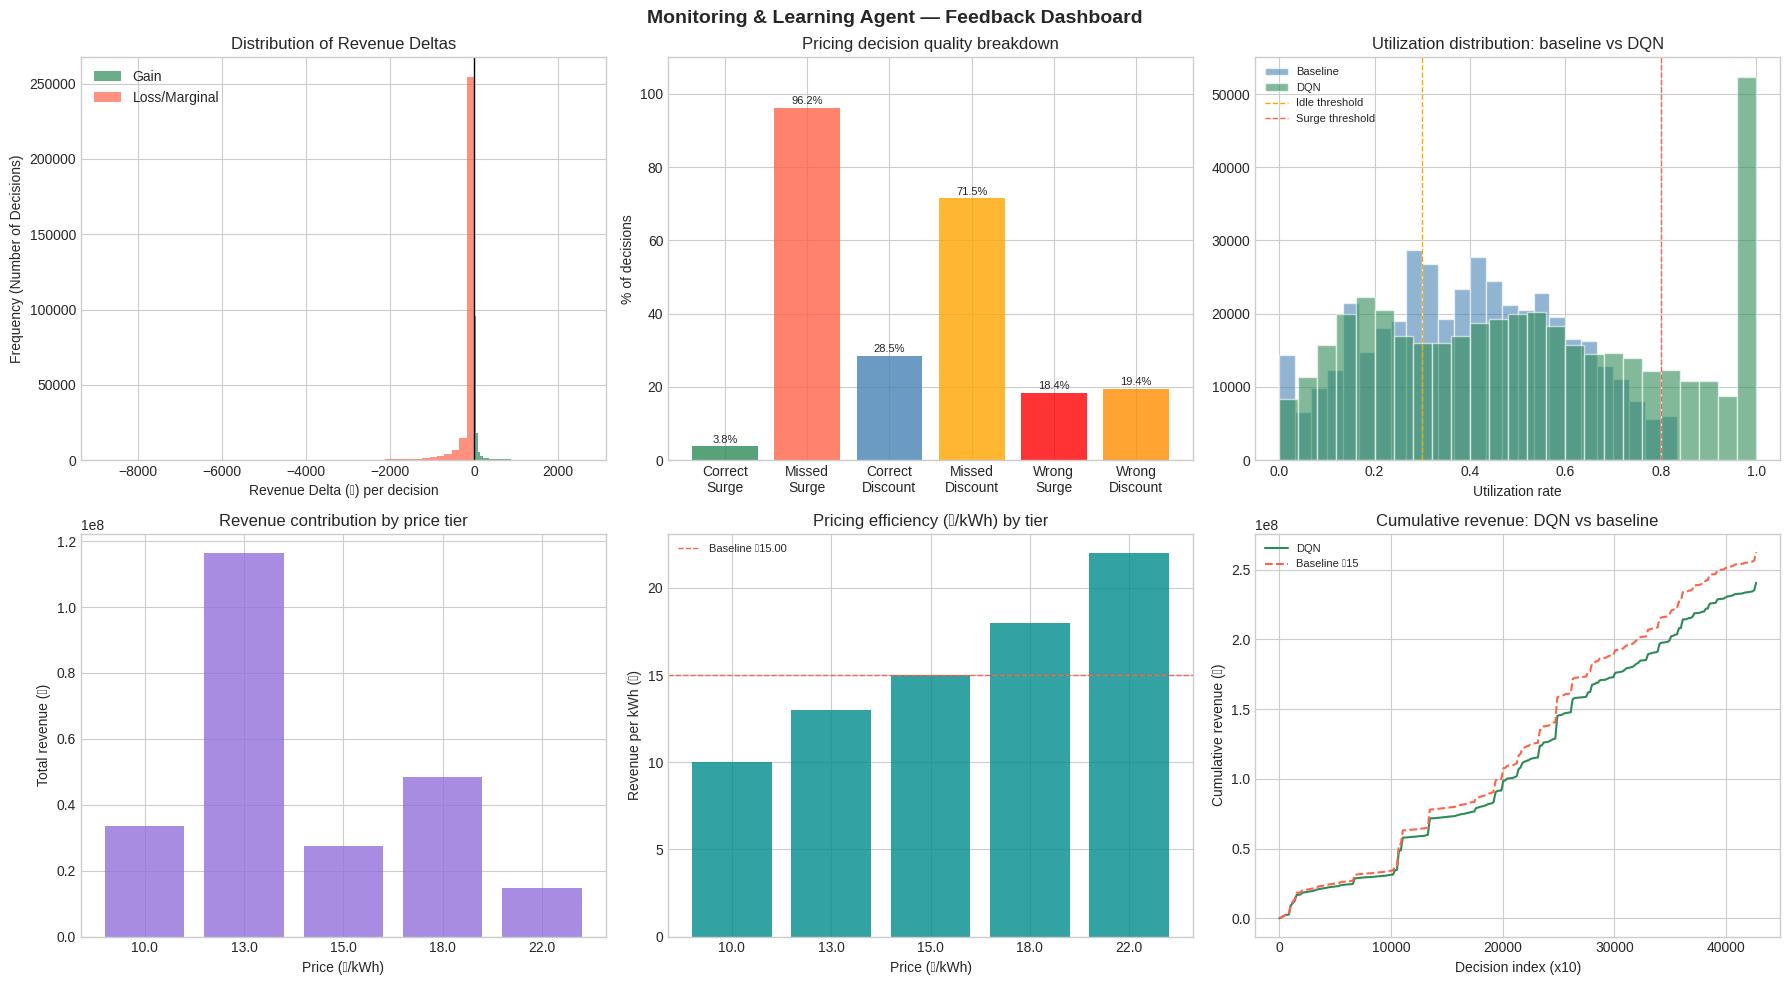

✅ Saved → monitoring_feedback_dashboard.png
✅ Saved → monitoring_cycle2_feedback.csv


In [ ]:
import time
import torch
import numpy as np


class EVChargingEnv(gym.Env):
    PRICE_TIERS = np.array([10.0, 13.0, 15.0, 18.0, 22.0])
    BASELINE    = 15.0

    def __init__(self, xgb_model, df, zone_capacity_dict, max_steps_per_episode=168):
        super().__init__()
        self.model      = xgb_model
        self.data       = df.reset_index(drop=True)
        self.total_rows = len(self.data)
        self.n_steps    = min(max_steps_per_episode, self.total_rows)
        self.action_space      = spaces.Discrete(len(self.PRICE_TIERS))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)
        self.start_idx = 0
        self.t = 0

    def _get_obs(self):
        row = self.data.iloc[self.start_idx + self.t]
        return np.array([
            row['hour'],
            row['day_of_week'],
            row['utilization_rate'],
            row.get('lag_price_1h',       self.BASELINE),
            row.get('lag_price_24h',      self.BASELINE),
            row.get('rolling_elasticity', -0.3),
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        max_valid_start = max(0, self.total_rows - self.n_steps - 1)
        self.start_idx = random.randint(0, max_valid_start)
        return self._get_obs(), {}

    def step(self, action):
        price = self.PRICE_TIERS[action]
        current_row_idx = self.start_idx + self.t
        row   = self.data.iloc[current_row_idx]
        feat_row                  = row[feature_cols].copy()
        feat_row['retail_tariff'] = price
        feat_df = pd.DataFrame(feat_row).T[self.model.feature_names_in_]
        for col in feat_df.columns:
            feat_df[col] = pd.to_numeric(feat_df[col])
        raw_volume     = float(self.model.predict(feat_df)[0])
        price_ratio    = price / self.BASELINE
        vol_multiplier = max(0.2, 1.0 - ((price_ratio - 1.0) * 1.5))
        volume         = max(raw_volume * vol_multiplier, 0.0)
        cap     = row['capacity'] if row['capacity'] > 0 else 1.0
        util    = min(volume / cap, 1.0)
        revenue = price * volume
        if util > 0.75:   util_bonus = 0.85
        elif util > 0.40: util_bonus = 1.25
        elif util > 0.20: util_bonus = 1.0
        else:             util_bonus = 0.75
        price_penalty = 0
        if price == 22.0 and util < 0.60:
            price_penalty = revenue * 0.45
        if price == 18.0 and util < 0.40:
            price_penalty = revenue * 0.25
        if price == 10.0 and util > 0.50:
            price_penalty = revenue * 0.20
        cong_penalty = max(0, util - 0.80) * 25
        idle_penalty = max(0, 0.35 - util) * 35
        raw_reward   = (revenue * util_bonus) - cong_penalty - idle_penalty - price_penalty
        reward       = raw_reward / 1000.0
        info = {'price': price, 'volume': volume, 'util': util, 'revenue': revenue}
        self.t += 1
        done = self.t >= self.n_steps
        obs  = self._get_obs() if not done else np.zeros(6, dtype=np.float32)
        return obs, reward, done, False, info


env   = EVChargingEnv(xgb_model, df_eval, {})
agent = DQNAgent(state_dim=6, action_dim=5)
rewards_log, revenue_log, loss_log, epsilon_log = [], [], [], []

print("🔁 FEEDBACK LOOP CYCLE 2 — Retraining with monitoring signals applied...")
print(f"{'Episode':>8} | {'Reward':>10} | {'Revenue':>10} | {'ε':>6} | {'Loss':>8}")
print("─" * 55)

for ep in range(300):
    state, _   = env.reset()
    ep_reward  = 0.0
    ep_revenue = 0.0
    ep_losses  = []
    while True:
        action                        = agent.act(state)
        next_s, reward, done, _, info = env.step(action)
        agent.remember(state, action, reward, next_s, done)
        loss = agent.learn()
        if loss is not None:
            ep_losses.append(loss)
        ep_reward  += reward
        ep_revenue += info['revenue']
        state       = next_s
        if done: break
    rewards_log.append(ep_reward)
    revenue_log.append(ep_revenue)
    epsilon_log.append(agent.epsilon)
    loss_log.append(np.mean(ep_losses) if ep_losses else 0.0)
    if ep % 50 == 0 or ep == 299:
        print(f"{ep:>8} | {ep_reward:>10.1f} | {ep_revenue:>10.1f} "
              f"| {agent.epsilon:>6.3f} | {loss_log[-1]:>8.4f}")
print("\n✅ Cycle 2 training complete")

print("\n📊 Evaluating Retrained Agent (Vectorized Mode)...")
start_time = time.time()
n_rows = len(df_eval)

def safe_get(col_name, default_val):
    return df_eval[col_name].values if col_name in df_eval.columns else np.full(n_rows, default_val)

states_matrix = np.column_stack([
    df_eval['hour'].values,
    df_eval['day_of_week'].values,
    df_eval['utilization_rate'].values,
    safe_get('lag_price_1h', EVChargingEnv.BASELINE),
    safe_get('lag_price_24h', EVChargingEnv.BASELINE),
    safe_get('rolling_elasticity', -0.3)
]).astype(np.float32)
agent.epsilon = 0.0
states_tensor = torch.FloatTensor(states_matrix)
with torch.no_grad():
    q_values = agent.q_net(states_tensor)
    actions  = q_values.argmax(dim=1).numpy()
chosen_prices = EVChargingEnv.PRICE_TIERS[actions]
eval_xgb_df = df_eval[feature_cols].copy()
eval_xgb_df['retail_tariff'] = chosen_prices
eval_xgb_df = eval_xgb_df[xgb_model.feature_names_in_]
for col in eval_xgb_df.columns: eval_xgb_df[col] = pd.to_numeric(eval_xgb_df[col])
raw_volumes     = xgb_model.predict(eval_xgb_df)
price_ratios    = chosen_prices / EVChargingEnv.BASELINE
vol_multipliers = np.clip(1.0 - ((price_ratios - 1.0) * 1.5), a_min=0.2, a_max=None)
volumes         = np.clip(raw_volumes * vol_multipliers, a_min=0.0, a_max=None)
caps            = np.where(df_eval['capacity'].values > 0, df_eval['capacity'].values, 1.0)
utils           = np.clip(volumes / caps, a_min=0.0, a_max=1.0)
revenues        = chosen_prices * volumes
baseline_utils  = np.clip(test_df['volume'].values / caps, a_min=0.0, a_max=1.0)
eval_df = pd.DataFrame({
    'price'               : chosen_prices,
    'volume'              : volumes,
    'utilization'         : utils,
    'dqn_revenue'         : revenues,
    'baseline_revenue'    : EVChargingEnv.BASELINE * volumes,
    'baseline_utilization': baseline_utils,
    'revenue_delta'       : revenues - (EVChargingEnv.BASELINE * volumes)
})
scorecard = compute_and_print_scorecard(eval_df=eval_df, training_rewards=rewards_log)
monitor   = MonitoringAgent(eval_df)
report    = monitor.run()
print_monitoring_report(report, eval_df)
plot_monitoring_report(monitor.df, report)
pd.DataFrame(report['feedback_signals']).to_csv("monitoring_cycle2_feedback.csv", index=False)
print("✅ Saved → monitoring_cycle2_feedback.csv")